Q1. (Understanding & Dataset Creation)
Create a synthetic dataset using make_blobs with:
n_samples=500
centers=4
cluster_std=0.70
Convert it into a DataFrame with column names Feature1 and Feature2.
Display the first 10 rows and the shape of the dataset.

In [3]:
import pandas as pd
from sklearn.datasets import make_blobs
#Generate synthetic dataset
X, y = make_blobs(n_samples=500, centers=4, cluster_std=0.70, random_state=42)
#Convert to DataFrame
df = pd.DataFrame(X, columns=["Feature1", "Feature2"])
# Display first 10 rows and shape of the Dataset
print(df.head(10))
print("\nShape of the Dataset:", df.shape)


   Feature1  Feature2
0 -8.033836  6.831299
1 -8.767448 -6.918116
2  6.172741  1.407361
3 -2.783673  7.989826
4 -6.038777 -7.165762
5 -6.298392 -7.479368
6 -7.046269  7.256281
7 -6.690307 -6.915276
8  3.892545  1.873504
9 -7.317000 -6.861846

Shape of the Dataset: (500, 2)


Q2. (Data Scaling)
Apply Standard Scaling on the features created in Q1.
Use StandardScaler from sklearn.
Store the scaled data in X_scaled.
Show the first 5 rows of the scaled data.

In [10]:
from sklearn.preprocessing import StandardScaler

# Assuming df from Q1 is already created
scaler = StandardScaler()

# Fit and transform the features
X_scaled = scaler.fit_transform(df)

# Convert back to DataFrame for readability
df_scaled = pd.DataFrame(X_scaled, columns=["Feature1", "Feature2"])

#first 5 rows
print(df_scaled.head())


   Feature1  Feature2
0 -0.888474  0.629907
1 -1.028908 -1.562875
2  1.831069 -0.235113
3  0.116557  0.814671
4 -0.506563 -1.602370


Q3. (Basic K-Means Clustering)
Apply KMeans clustering with n_clusters=3 on the scaled data.
Fit the model and predict cluster labels.
Add the cluster labels as a new column in the DataFrame.
Display the first 10 rows of the updated DataFrame.

In [13]:
from sklearn.cluster import KMeans

k_model = KMeans(n_clusters=3, random_state=42)

# Fit the model and predict cluster labels
clusters = k_model.fit_predict(df_scaled)

# Add cluster labels as a new column
df_scaled["Cluster"] = clusters

# Display first 10 rows
print(df_scaled.head(10))


   Feature1  Feature2  Cluster
0 -0.888474  0.629907        1
1 -1.028908 -1.562875        2
2  1.831069 -0.235113        0
3  0.116557  0.814671        1
4 -0.506563 -1.602370        2
5 -0.556260 -1.652385        2
6 -0.699425  0.697684        1
7 -0.631284 -1.562422        2
8  1.394574 -0.160771        0
9 -0.751251 -1.553901        2


Q4. (Visualizing Clusters)
Create a scatter plot using seaborn to visualize the clusters formed in Q3.
Use Feature1 on x-axis and Feature2 on y-axis.
Color the points based on the cluster labels (hue).
Add a proper title and labels to the plot.

Text(0, 0.5, 'Feature2 (Scaled)')

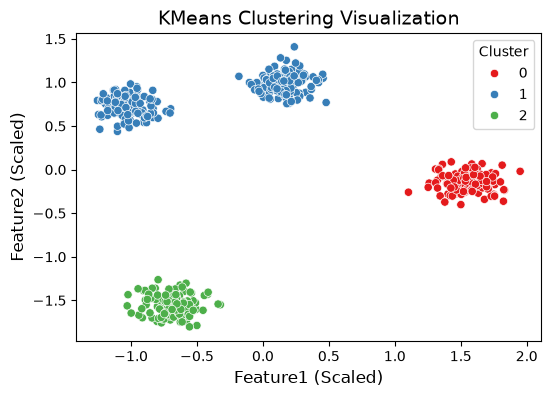

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
# Scatter plot of clusters
plt.figure(figsize=(6,4))
sns.scatterplot(
    x="Feature1", 
    y="Feature2", 
    hue="Cluster", 
    data=df_scaled, 
    palette="Set1")
# Add title and labels
plt.title("KMeans Clustering Visualization", fontsize=14)
plt.xlabel("Feature1 (Scaled)", fontsize=12)
plt.ylabel("Feature2 (Scaled)", fontsize=12)

Q5. (Elbow Method – Finding Optimal K)
Implement the Elbow Method to find the best number of clusters:
Try K values from 1 to 10.
Calculate and store the inertia (WSS) for each K.
Plot the Elbow graph (K vs Inertia) with markers.
Observe the graph and write which K value looks optimal.

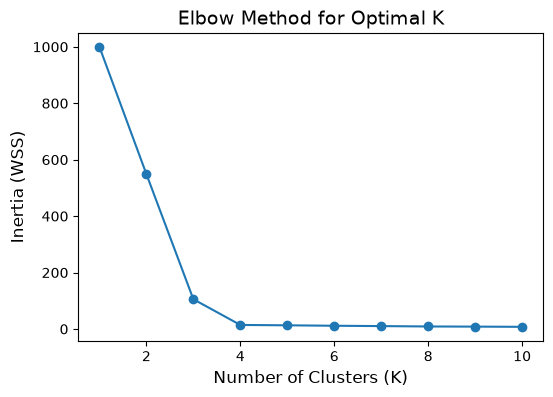

In [ ]:

# Calculate inertia (WSS) for K = 1 to 10
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_scaled[["Feature1", "Feature2"]])
    inertia.append(kmeans.inertia_)

# Plot the Elbow graph
plt.figure(figsize=(6,4))
plt.plot(K_range, inertia,marker='o')
plt.title("Elbow Method for Optimal K", fontsize=14)
plt.xlabel("Number of Clusters (K)", fontsize=12)
plt.ylabel("Inertia (WSS)", fontsize=12)
plt.show()

#The “elbow” point is where the inertia starts decreasing more slowly.
# sharp drop until around K = 3 or 4, after which the curve flattens.
# the optimal K will likely appear around 3 or 4.


Q6. (Final K-Means Model)
Based on the Elbow Method result from Q5:
Train a final KMeans model with the optimal number of clusters.
Use random_state=42.
Predict the cluster labels and add them to the DataFrame.
Print the number of data points in each cluster.

In [ ]:

# Train final KMeans model with optimal K (here K=4)
final_kmeans = KMeans(n_clusters=4, random_state=42)

# Fit and predict cluster labels
final_clusters = final_kmeans.fit_predict(df_scaled[["Feature1", "Feature2"]])

# Add final cluster labels to DataFrame
df_scaled["FinalCluster"] = final_clusters

# Print number of data points in each cluster
print(df_scaled["FinalCluster"].value_counts().sort_index())


FinalCluster
0    125
1    125
2    125
3    125
Name: count, dtype: int64


Q7. (Visualizing Final Clusters)
Create a clear scatter plot of the final clusters obtained in Q6.
Use different colors for each cluster.
Add cluster centroids to the plot (optional but recommended).
Give a proper title: “K-Means Clustering Results”.

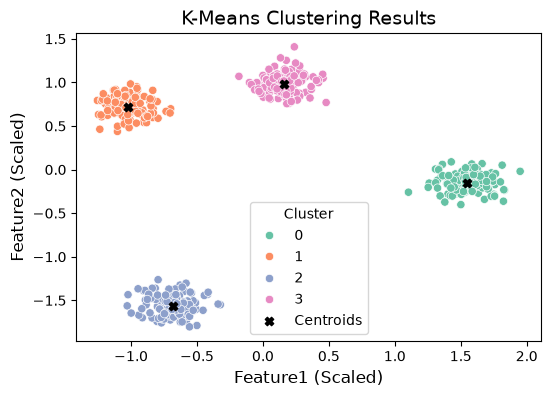

In [ ]:
# Get cluster centroids from the final model
centroids = final_kmeans.cluster_centers_
# Scatter plot of final clusters
plt.figure(figsize=(6,4))
sns.scatterplot(
    x="Feature1", 
    y="Feature2", 
    hue="FinalCluster", 
    data=df_scaled, 
    palette="Set2")

# Plot centroids
plt.scatter(
    centroids[:,0], centroids[:,1], 
    c="black", marker="X", label="Centroids")
# Add title and labels
plt.title("K-Means Clustering Results", fontsize=14)
plt.xlabel("Feature1 (Scaled)", fontsize=12)
plt.ylabel("Feature2 (Scaled)", fontsize=12)
plt.legend(title="Cluster")
plt.show()

Q8. (Real Dataset Application)
Load any real-world dataset suitable for clustering (e.g., Iris, Mall Customers, or
any dataset of your choice).
Select only numerical features.
Scale the data.
Apply KMeans with a suitable number of clusters.
Add cluster labels to the DataFrame and show value counts of each cluster.

In [ ]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

#Load the Iris dataset
iris = load_iris()
df_iris = pd.DataFrame(iris.data, columns=iris.feature_names)

#Select only numerical features (Iris dataset is already numerical)
X = df_iris

#Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#Apply KMeans with suitable number of clusters (here K=3 for Iris species)
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

#Add cluster labels to DataFrame
df_iris["Cluster"] = clusters

#Show value counts of each cluster
print(df_iris["Cluster"].value_counts())


Cluster
0    96
1    33
2    21
Name: count, dtype: int64


Q9. (Elbow Method on Real Dataset)
On the real dataset used in Q8:
Apply the Elbow Method (K = 1 to 10).
Plot the Elbow curve.
Decide the optimal K and train the final KMeans model.
Visualize the clusters (if the dataset has 2 main features) or print cluster sizes.

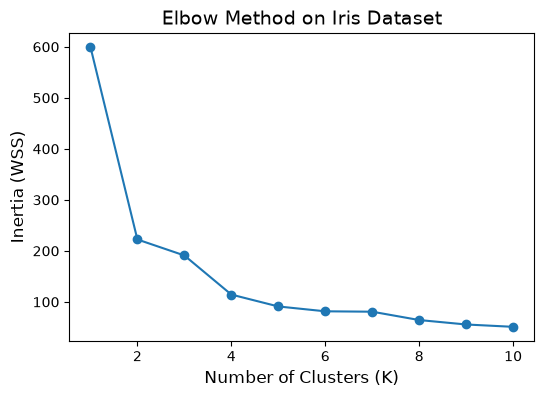

Cluster
0    96
1    33
2    21
Name: count, dtype: int64


In [ ]:
inertia = []
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
#Plot Elbow curve
plt.figure(figsize=(6,4))
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method on Iris Dataset", fontsize=14)
plt.xlabel("Number of Clusters (K)", fontsize=12)
plt.ylabel("Inertia (WSS)", fontsize=12)
plt.show()
# Train final KMeans model with optimal K (likely 3 for Iris)
final_kmeans = KMeans(n_clusters=3, random_state=42)
final_clusters = final_kmeans.fit_predict(X_scaled)
#Print cluster sizes
print(df_iris["Cluster"].value_counts().sort_index())


Q10. (Mini Project – Complete Clustering Pipeline)
Choose a real-world dataset for customer segmentation or similar use case.
Perform the complete pipeline:
1. Load and explore the data
2. Select numerical features and scale them
3. Apply Elbow Method to find optimal K
4. Train final KMeans model
5. Visualize the clusters

   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Genre                   200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 8.9 KB
None


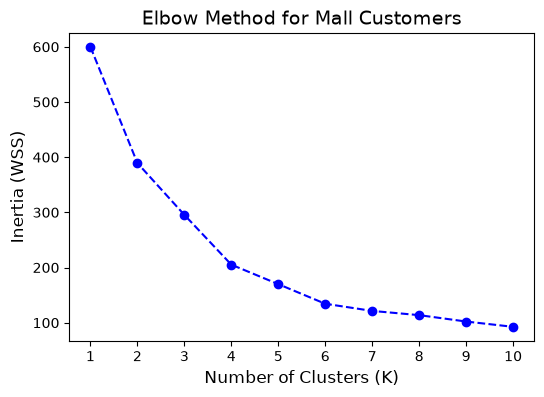

Cluster
0    58
1    40
2    26
3    45
4    31
Name: count, dtype: int64


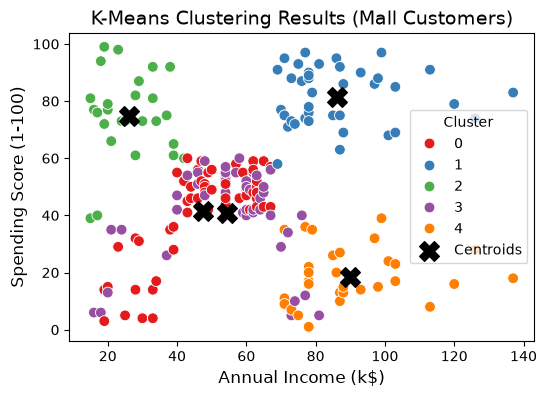

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
# Load dataset
df = pd.read_csv("Mall_Customers.csv")
print(df.head())
print(df.info())
# Select Numerical Features and Scale Them
X = df[["Age", "Annual Income (k$)", "Spending Score (1-100)"]]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# Apply Elbow Method to Find Optimal K
inertia = []
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
plt.figure(figsize=(6,4))
plt.plot(K_range, inertia, marker='o', linestyle='--', color='b')
plt.title("Elbow Method for Mall Customers", fontsize=14)
plt.xlabel("Number of Clusters (K)", fontsize=12)
plt.ylabel("Inertia (WSS)", fontsize=12)
plt.xticks(K_range)
plt.show()
# Train Final KMeans Model (Optimal K ~ 5)
final_kmeans = KMeans(n_clusters=5, random_state=42)
clusters = final_kmeans.fit_predict(X_scaled)
df["Cluster"] = clusters
print(df["Cluster"].value_counts().sort_index())
# Visualize the Clusters (Annual Income vs Spending Score)
plt.figure(figsize=(6,4))
sns.scatterplot(
    x=df["Annual Income (k$)"], 
    y=df["Spending Score (1-100)"], 
    hue=df["Cluster"], 
    palette="Set1", 
    s=60
)
# Plot centroids (unscaled back to original space)
centroids = final_kmeans.cluster_centers_
centroids_unscaled = scaler.inverse_transform(centroids)
plt.scatter(
    centroids_unscaled[:,1], centroids_unscaled[:,2], 
    s=200, c="black", marker="X", label="Centroids"
)
plt.title("K-Means Clustering Results (Mall Customers)", fontsize=14)
plt.xlabel("Annual Income (k$)", fontsize=12)
plt.ylabel("Spending Score (1-100)", fontsize=12)
plt.legend(title="Cluster")
plt.show()
